# Week-9: Digital Modulation Schemes
So far we have seen examples of analog communications systems like AM and FM. Last week, we analysed ADS-B signals which are OOK signals. But we know that modern communictions systems are high data-rate digital ones, such as cellular, WiFi, Bluetooth. In this lab we will look at some of the basic building blocks of digital communications. Our focus will be on **QPSK** modulation and demodulation, which is a common digital modulation scheme. For this purpose we will build a GNU Radio flowgraph step-by-step to generate a QPSK signal (**transmitter part**), then will complete it with a **receiver part**. We will also cover communication mismatches or problems and how to eliminate them in the **synchronization part**. 

After the lab we will cover and have a better understanding of the following concepts: 
* Send/Receive **digital data** (bytes)
* **Constellation** diagram
* **Pulse shaping**
* **Synchronization**
* **Decoding**

## QPSK Walkthrough with GNU Radio & Task-1
Digital communications systems operate by mapping digital data **bits into symbols**. Modulation scheme defines the mapping. QPSK uses two bits per symbol so there are 4-possible points in constellation diagram. Here is how it looks like in **gray-coded** scheme. 

![const](./nbimages/200px-QPSK_Gray_Coded.svg.png)

### A-Transmitter Part
#### 1. Digital Data Generation
As there is no hardware limiting the data stream, we need to use **Throttle** block in our flowgraph. We will generate constant or random bytes depending on our choice defined by **QT GUI Chooser**. Let's see data generated in time scope. 

![QPSK1GenerateData](./nbimages/QPSKDemo1TxGenerate.png)

#### Q1: **Your Screenshot: Put a screenshot of time sink for randomly generated digital data (10 pts)**


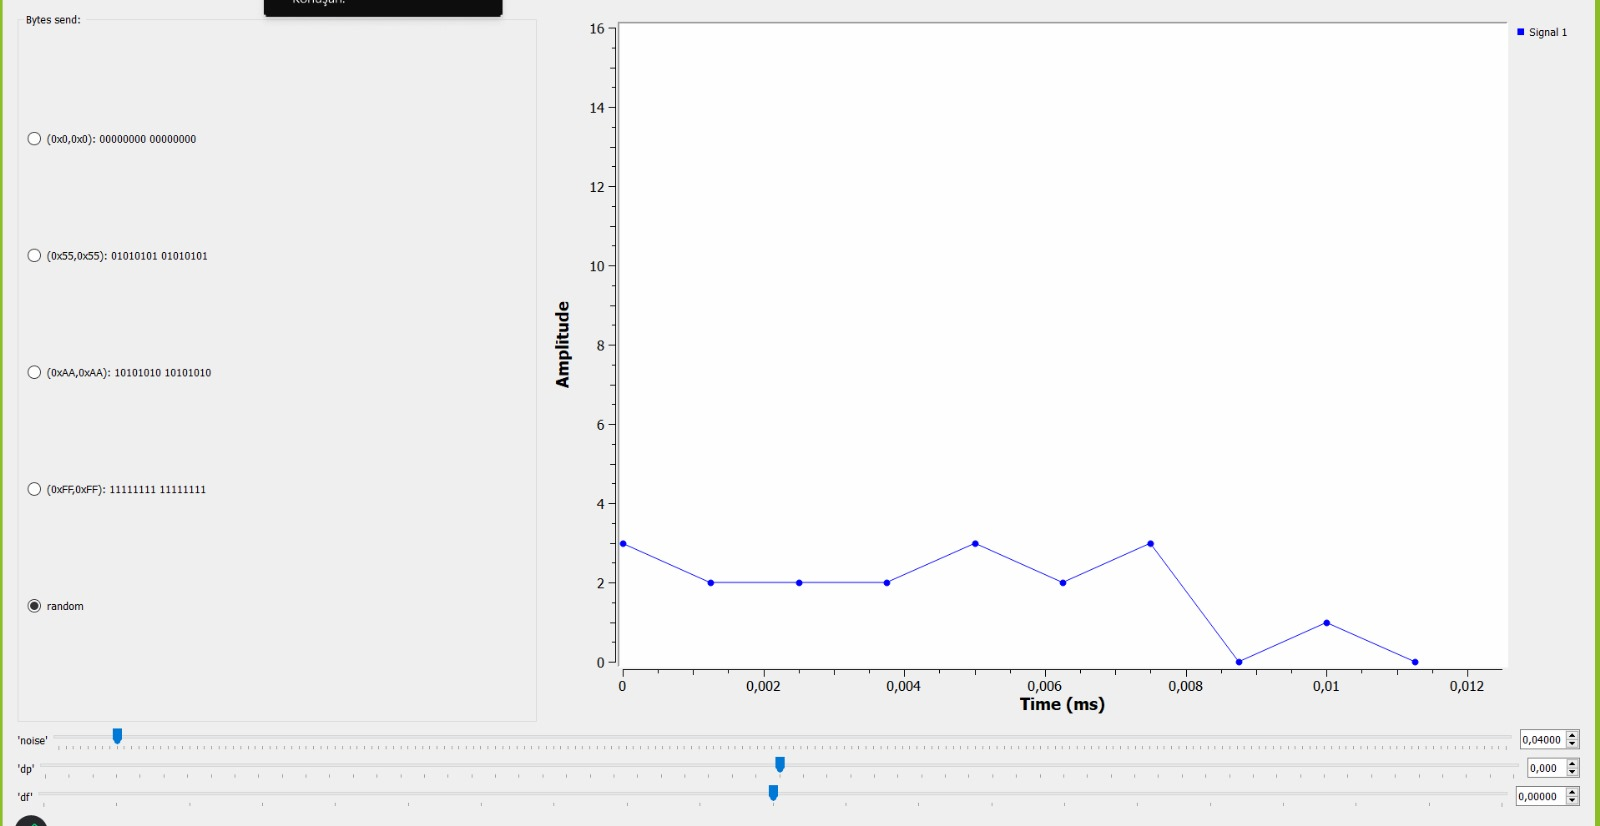

#### 2. Complex Data Conversion
The combination of **Packed to Unpacked** followed by **Chunks to Symbols** handles the general case of mapping from a stream of bytes or shorts into arbitrary float or complex symbols. So, let's have a look at data after complex data conversion happens. 

![QPSK2Complex](./nbimages/QPSKDemo2TxComplex.png)
#### Q2: **Your Screenshot: Put a screenshot of time sink for randomly generated complex data (10 pts)**

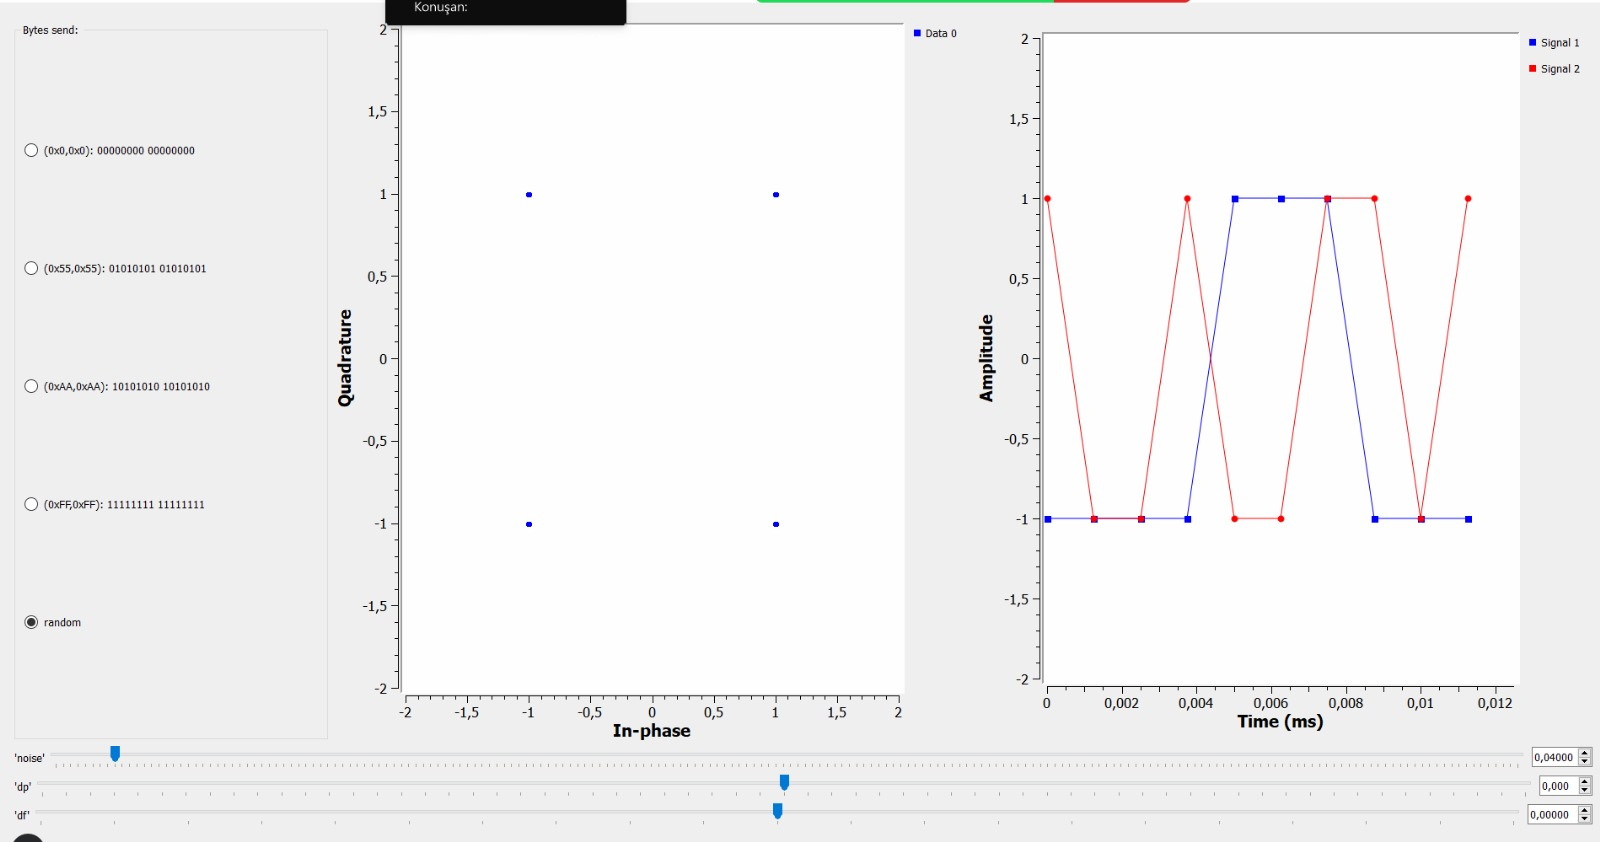

#### 3. Symbol Forming
Then we form rectangular symbols by adding 8 samples together using **Repeat**. Observe output of repeat block. 

![QPSK3RectPulses](./nbimages/QPSKDemo3TxRectPulses.png)

#### Q3: **Your Screenshot: Put a screenshot of frequency sink for randomly rectangular pulses (10 pts)**


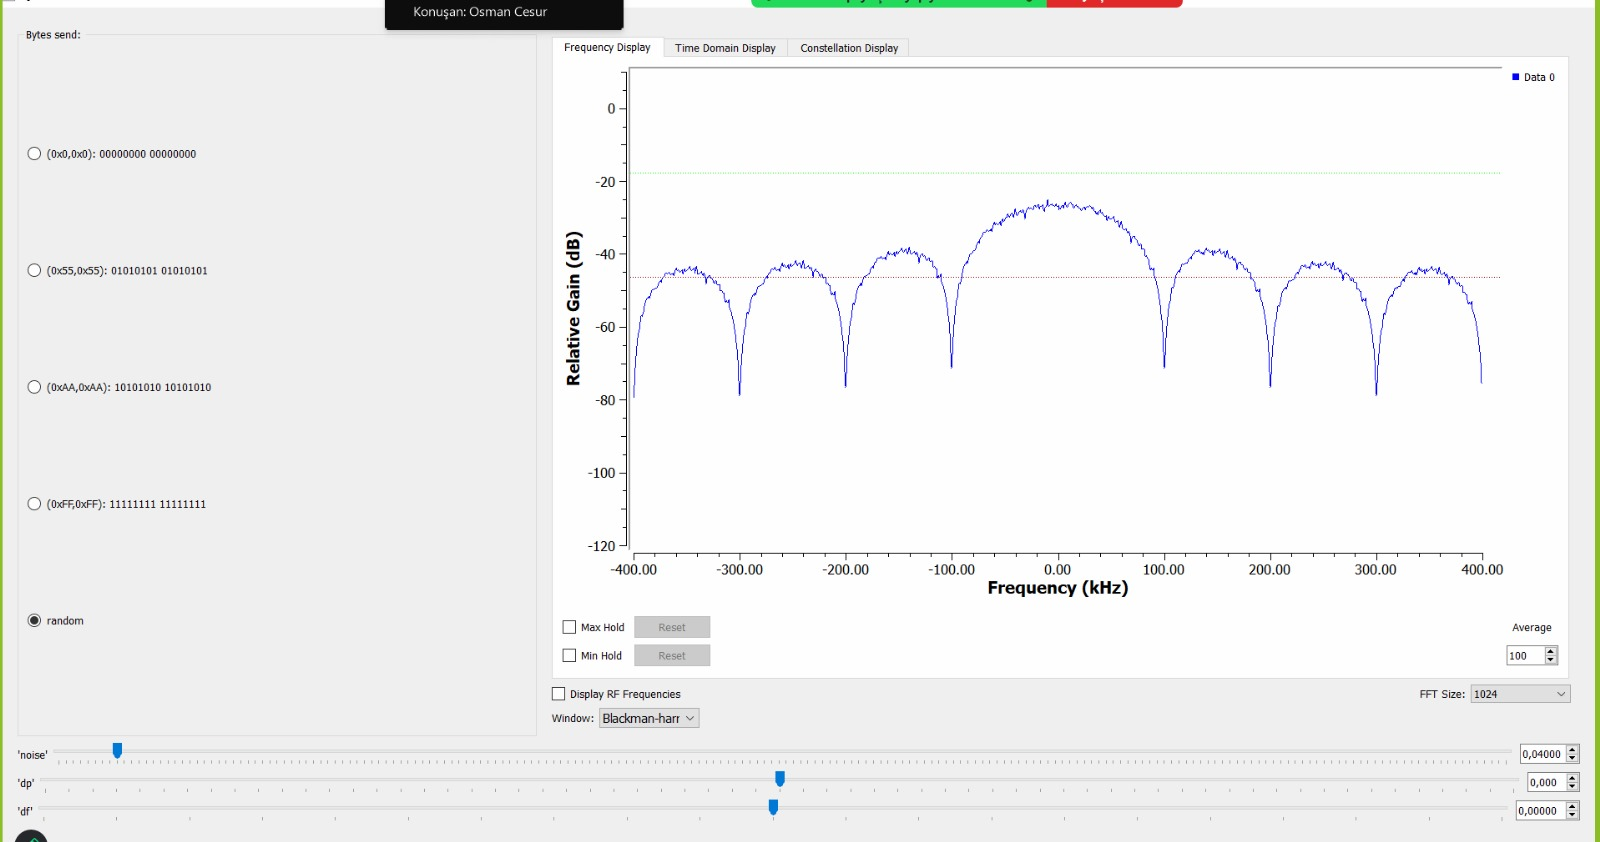

#### 4. Pulse Shaping
Now we will use **Root Raised Cosine Filter** to improve spectral efficiency of transmission. This is also called transmit filtering. Wireless communications are subject to some regulations unique to country. It filters the signal using a raised cosine pulse shape filter. Compare signal before and after filtering. You should observe after filtering side lobes getting lower to produce better SNR. In time domain, smooth transitions replace sharp transitions in rectangular pulses. 

![QPSK4RRC](./nbimages/QPSKDemo4TxRRC.png)

#### Q4: **Your Screenshot: Put a screenshot of frequency sinks after transmit filtering (10 pts)**


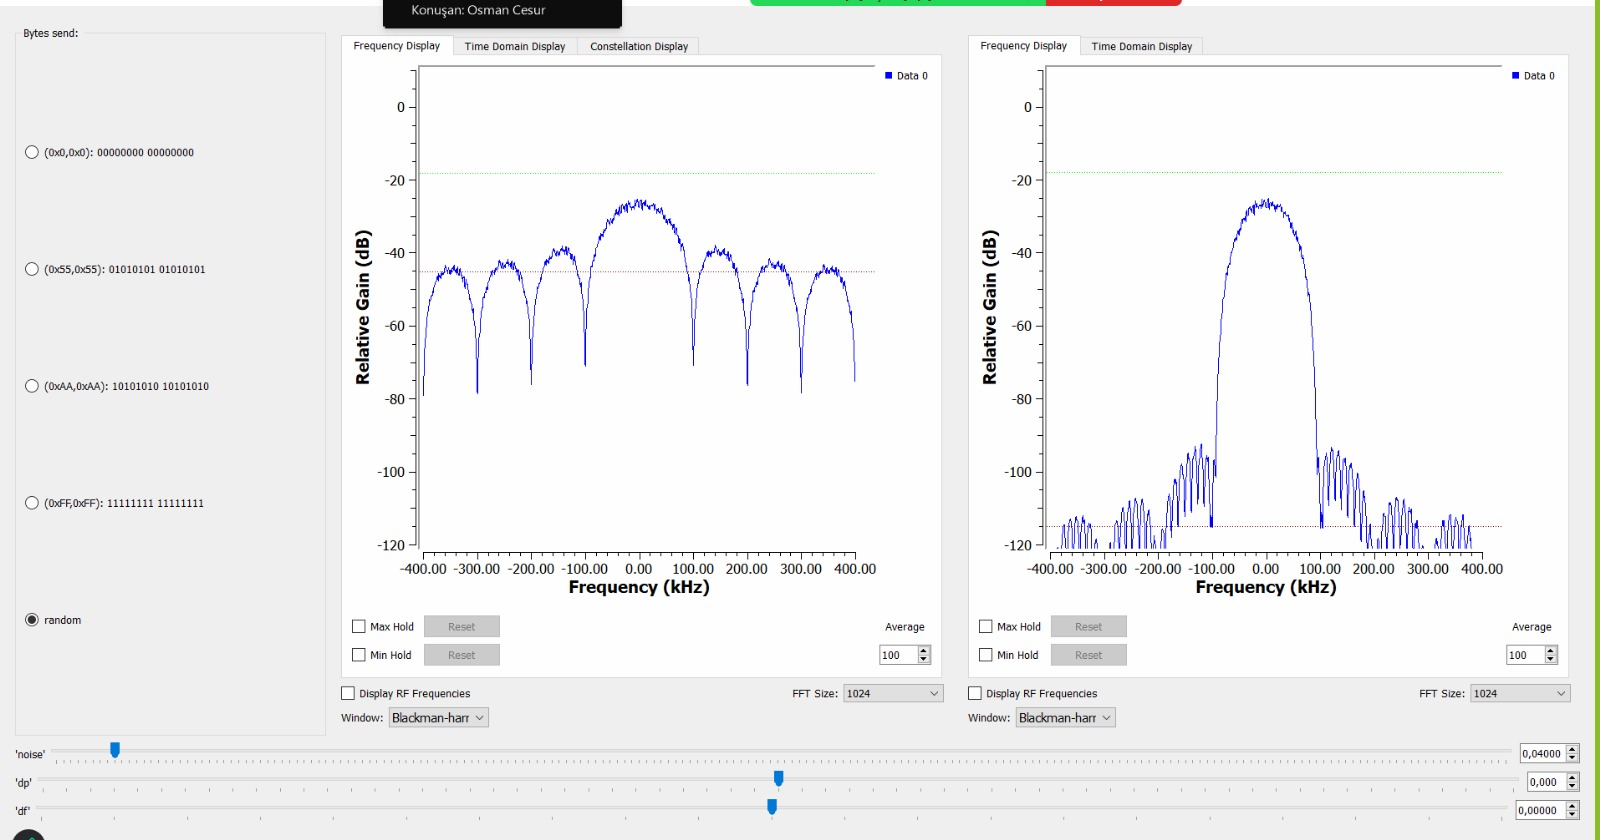

#### 5. Modulating with carrier
We are ready to send the signal at carrier frequency of our choice. To do this use **Frequency Translating FIR Filter**. We choose a carrier frequency of **100kHz**. We are also adding some **noise** to model channel propogation. Notice that our signal is shifted by 100kHz. Transmit part ends with **Virtual Sink** block. Virtual sink provides connection between transmit and receive parts. 

![QPSK5Transmit](./nbimages/QPSKDemo5TxTransmit.png)

#### Q5: **Your Screenshot: Put a screenshot of frequency sinks after modulating with the carrier (10 pts)**


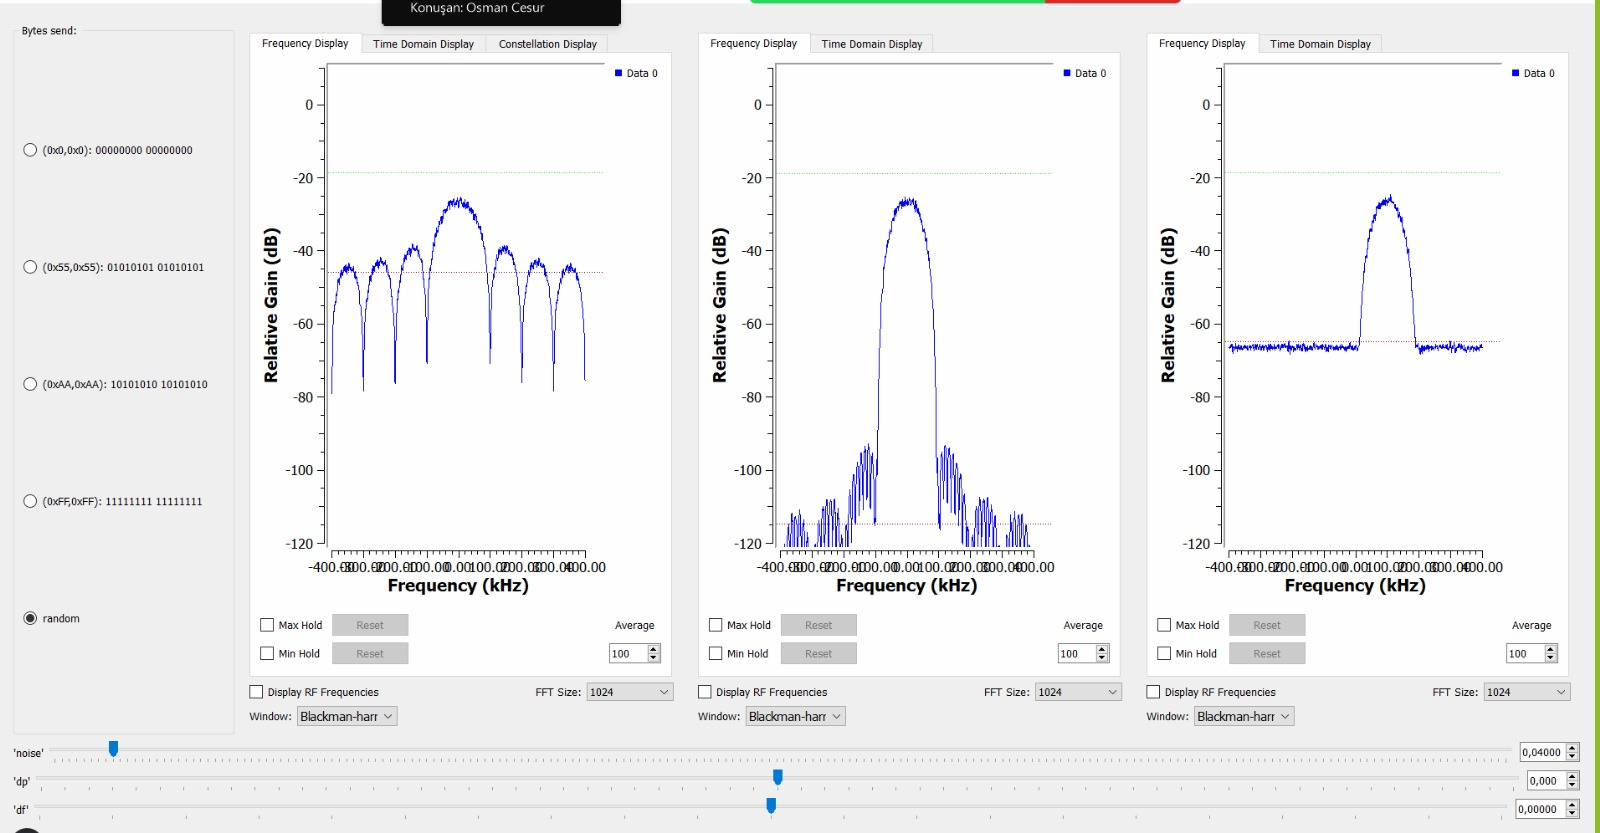

### B-Receiver Part
#### 6. Demodulating to Baseband
The first thing we do at the receive part is to demodulate the signal to the baseband with **Frequency Translating FIR Filter**. We obtain the same signal at 0 Hz. Though if you look at the constellation diagram we don't see what we are expecting. This is due to pulse shaping. 

![QPSK6Baseband](./nbimages/QPSKDemo6RxBaseband.png)

#### Q6: **Your Screenshot: Put a screenshot of constellation diagram (10 pts)**


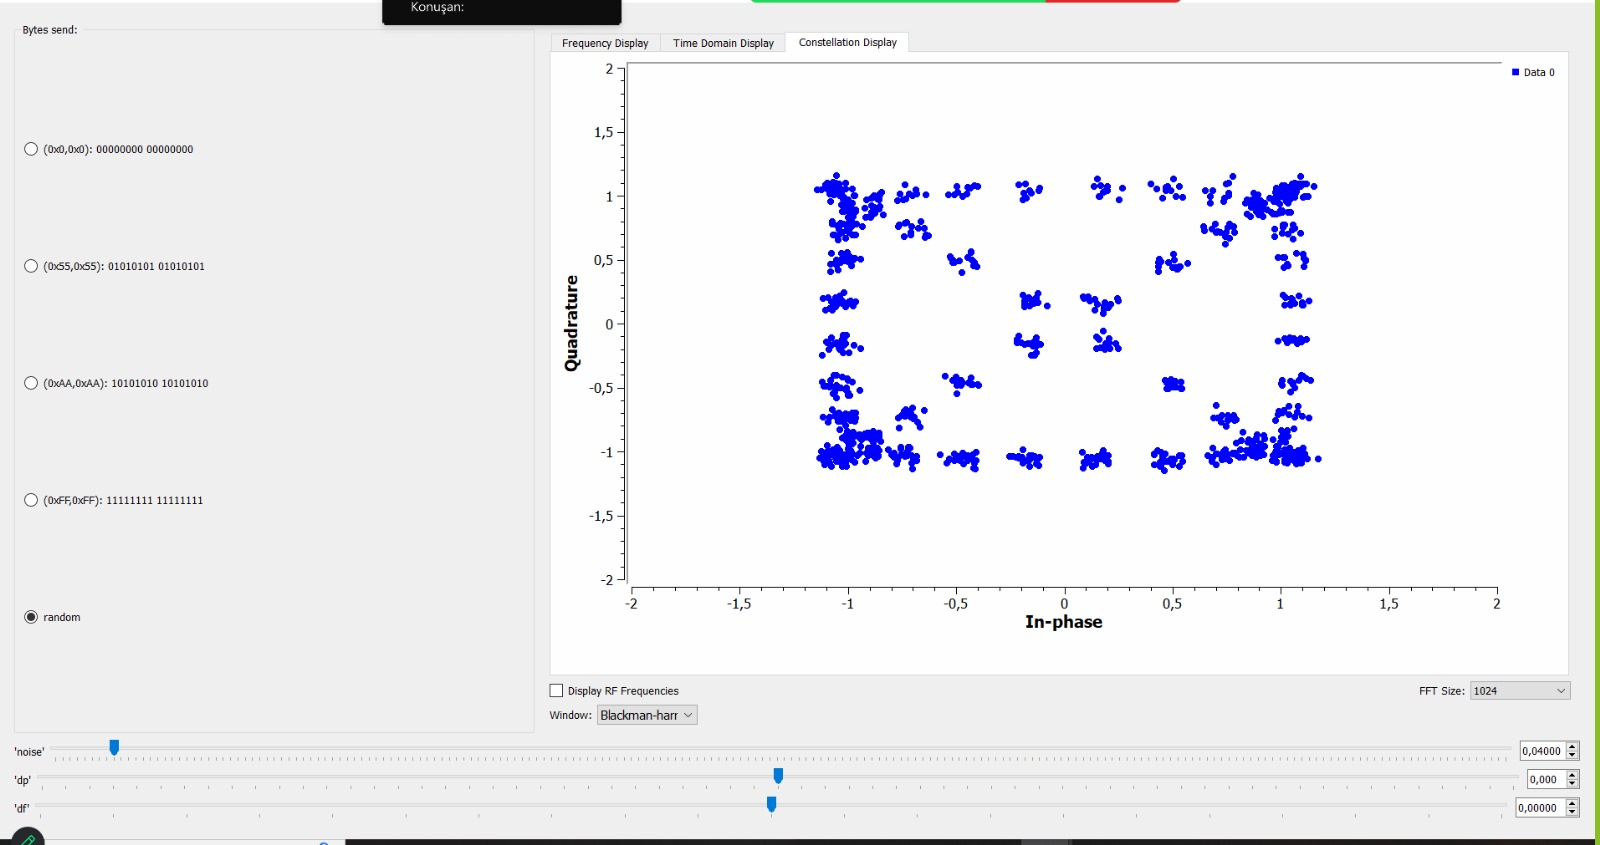

#### 7. Symbol Synchronization
What we need is **Symbol Sync** block to do synchronization. We need to specify 8 as samples per symbol parameter. The block uses **Mueller and Mueller** algorithm to do synchronization. Symbol Sync block adjusts for symbol clock drift in the incoming signal, ensuring that incoming pulses are sampled (for purposes of deciding which symbol was sent) at the “opening” of the eye. The block outputs exactly one sample per symbol interval.

**Note**: Do not use Costas Loop block at this stage!

![QPSK7SymbolSync](./nbimages/QPSKDemo7RxSymbolSync.png)

#### Q7: **Your Screenshot: Put a screenshot of constellation diagrams before and after symbol sync (10 pts)**


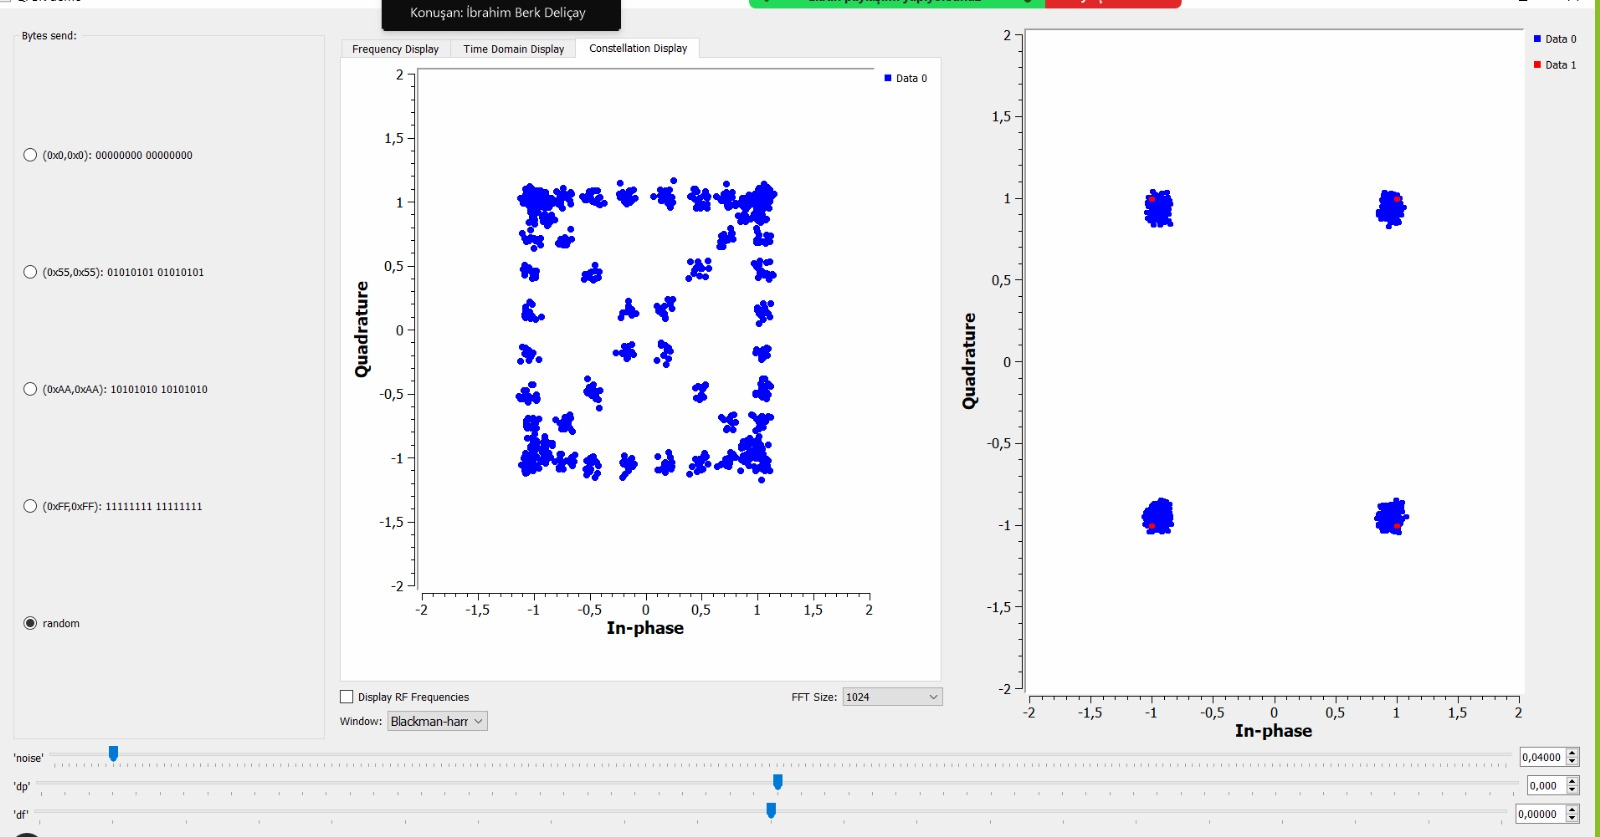

#### 8. Decoding
Finally, we can decode the constellation using **Constellation Soft Decoder** block according to parameters we define in **Constellation Object** block. **Binary Slicer** will output 0 or 1 where we form 8-bit packets using **Pack K Bits** block. We save the data in a file to examine later. 

![QPSK8Decode](./nbimages/QPSKDemo8RxDecode.png)

#### Q8: **Your Screenshot: Put a screenshot of hex view of output file `out.bin` when 0x55 is sent continuously. (10 pts)**


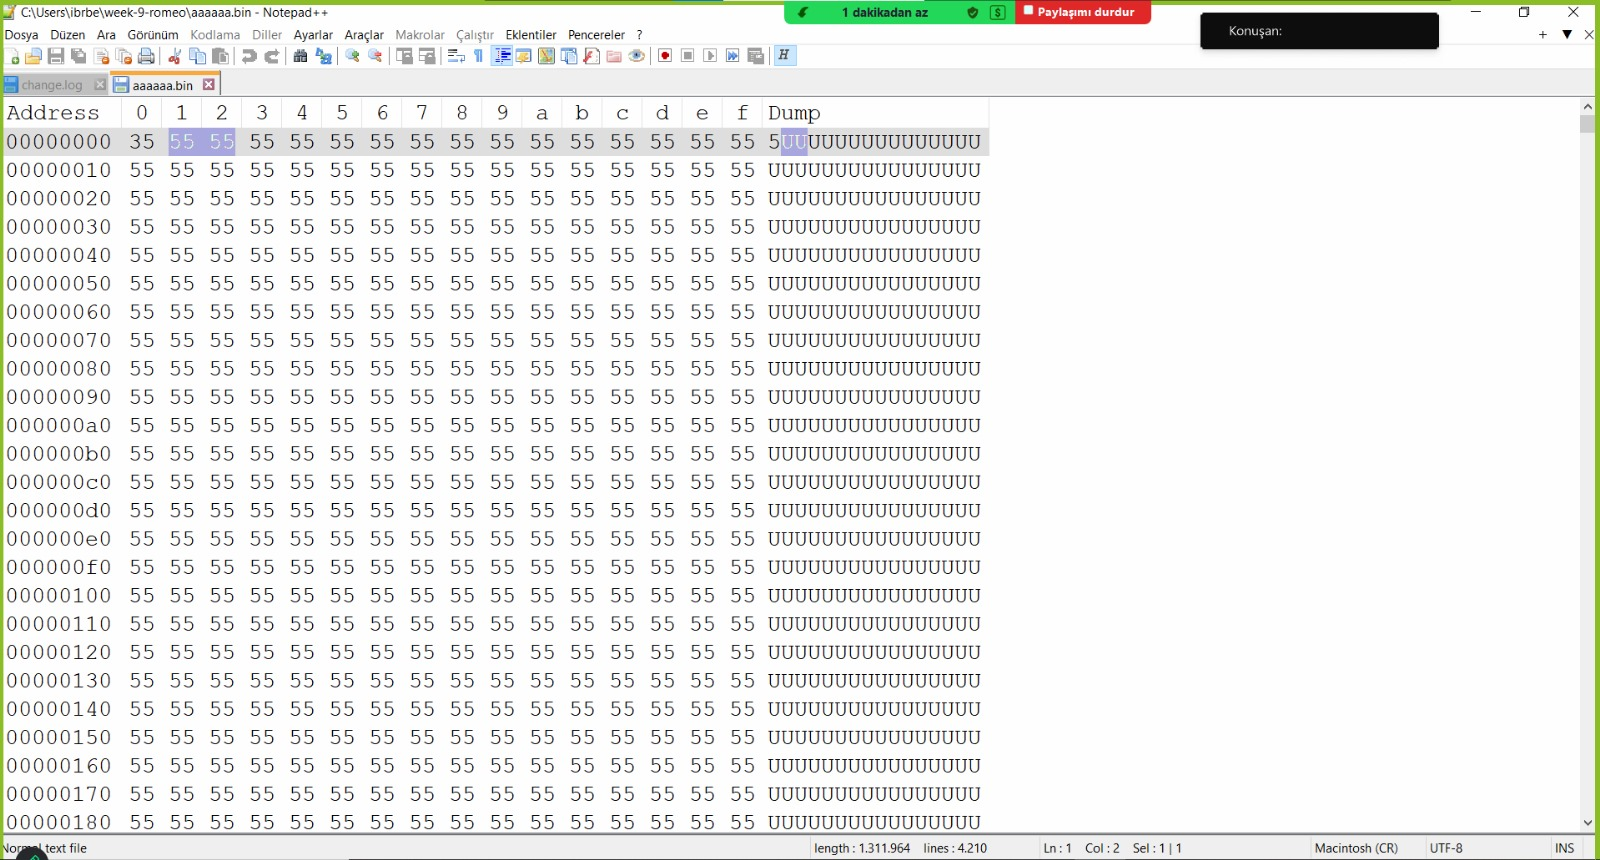

### C-Synchronization
Now, let's discuss one important factor that has huge impact on decoding performance at the receiver. We were able to tune to the exact frequency, 100kHz, in our flowgraph easily. But this is not often the case in the real world. There will always be **some offset** between transmitter and receiver local oscillator frequencies and phases. We can play with **QT GUI Range, dp** and **QT GUI Range, df** to see what happens when LOs are not perfectly synchronized. 

#### 9. Phase Offset
First play with dp, which corresponds to **phase difference** between transmitter and receiver. You should see that constellation diagram rotates and stays at a **fixed angle** depending on the dp value. 

#### Q9: **Your Screenshot: Put a screenshot of constellation diagrams with phase offset (10 pts)**


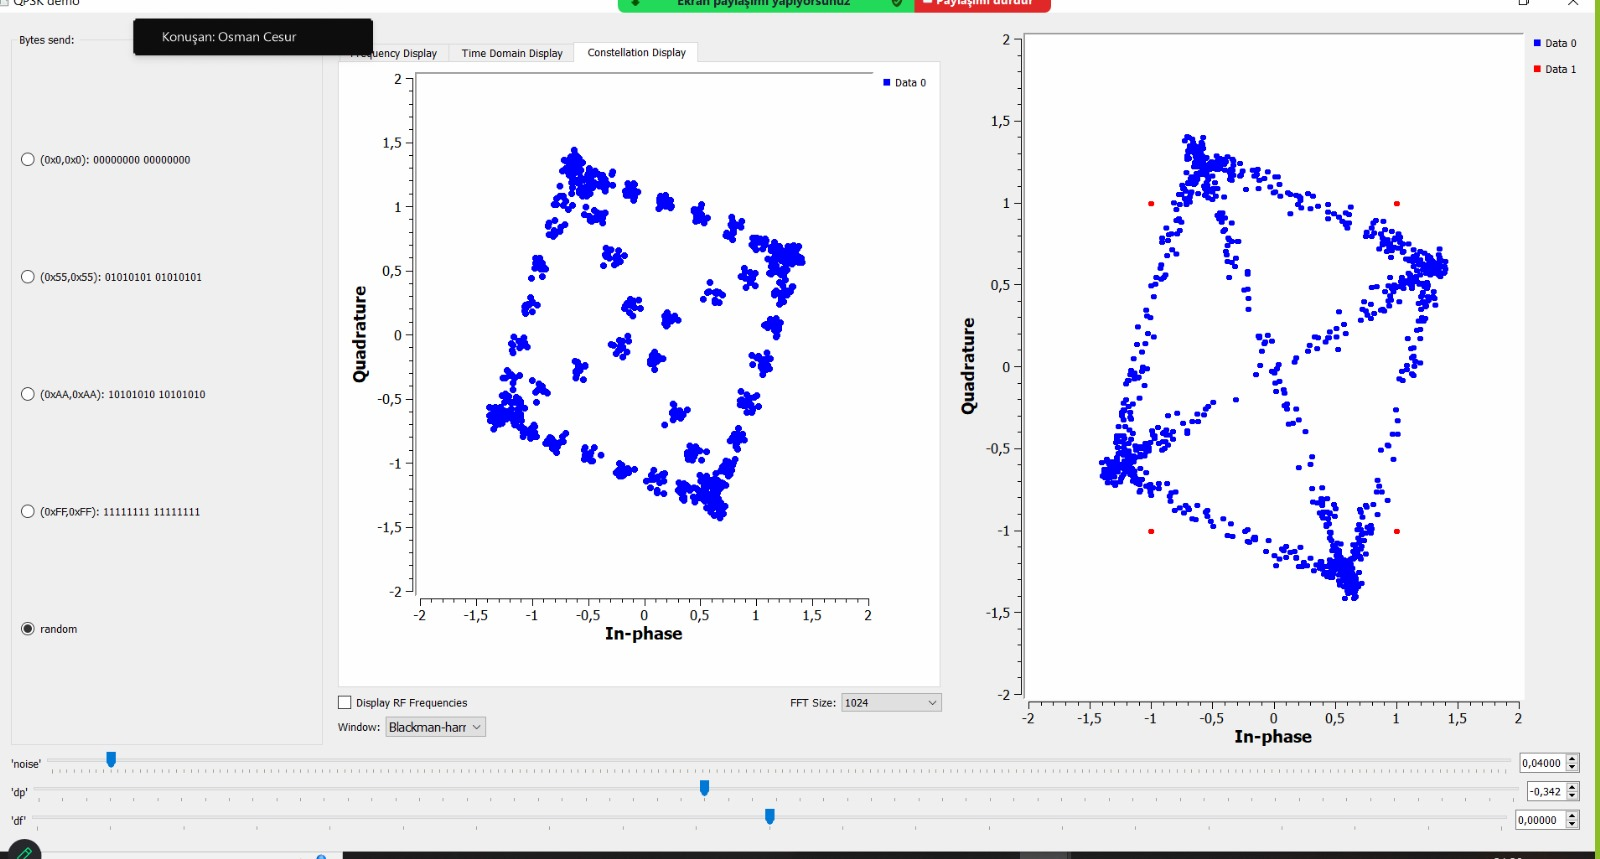

#### 10. Frequency Offset
Then play with df parameter simulating **frequency difference** between transmitter and receiver. You can observe that constellation diagram starts **rotating** when there is a shift in frequency! The symbols are undergoing rotation in the I/Q space at the rate 2π*df radians per second. 

#### Q10: **Your Screenshot: Put a screenshot of constellation diagrams with frequency offset (10 pts)**


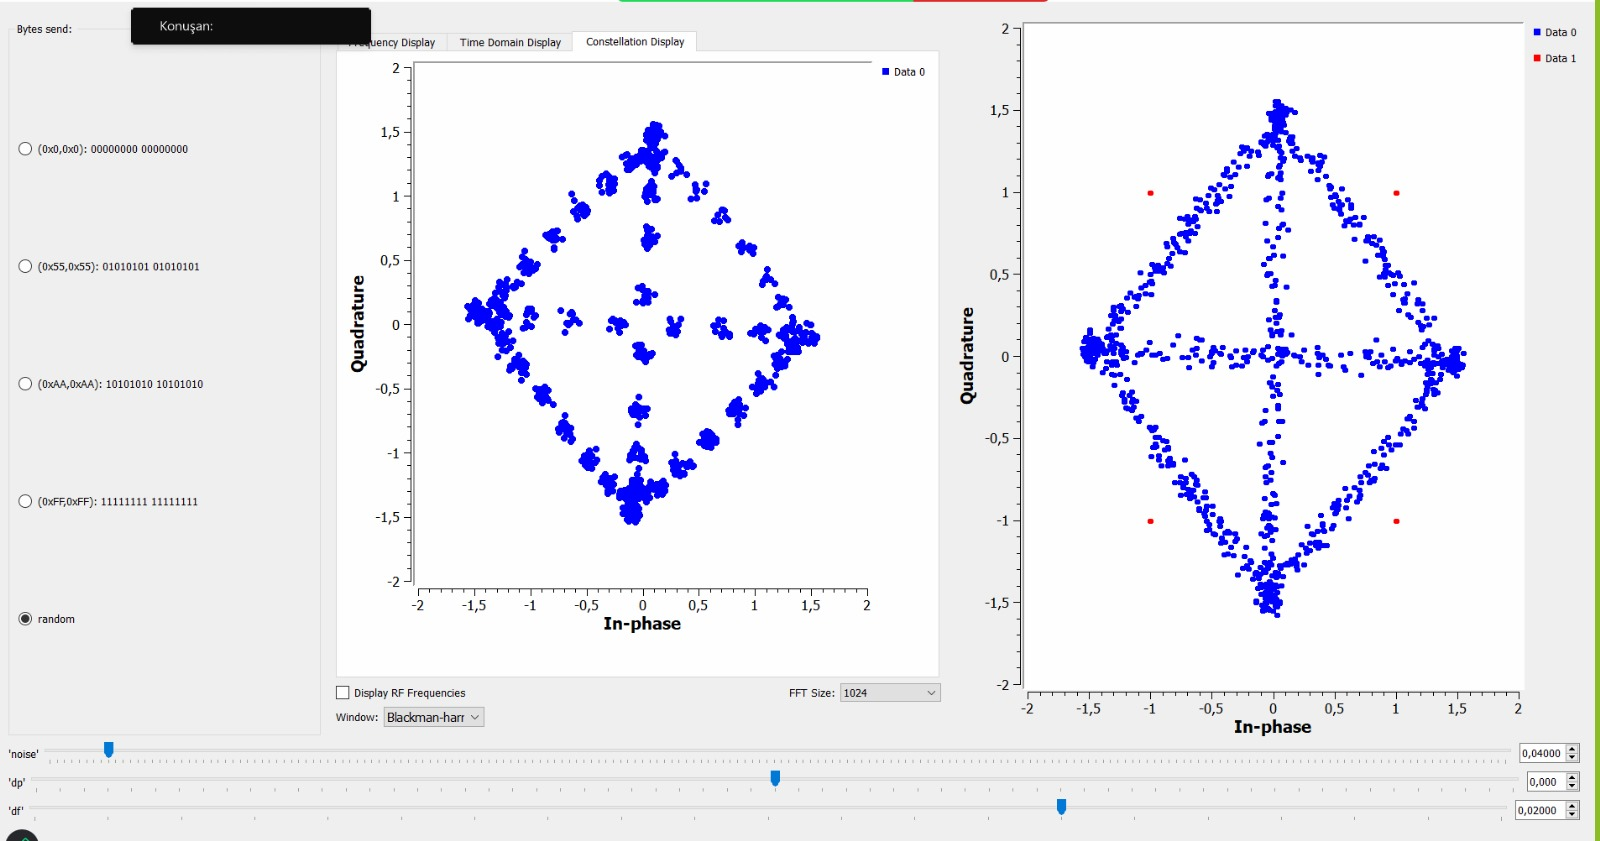

#### 11. Costas Loop
To compensate the frequency shift, we can use **Costas Loop** block. It adjusts for carrier frequency and phase offsets in the incoming signal.Place the block before symbol sync block, and observe that constellation does not rotate after using it. This block can be used in all phase modulations, but not in QAM modulations where both phase and amplitude vary. 

**Note**: Now use Costas Loop block before Symbol Sync block!

![QPSK8Costas](./nbimages/QPSKDemo9RxCostas.png)

# Task-2

## Q1: How do you compare transmitter and receiver in terms of complexity, i.e. which part do you think is harder to implement? Support your reasoning. (20 pts)

## A1: 
Verici : Verici; sinyal üretimi, modülasyon ve gönderim süreçlerini içerisinde barındırır.

Alıcı : Alıcı, gelen sinyali alıp demodüle ederek doğru şekilde çözümlemelidir. Burada faz ve frekans farkını tespit edip alıcı ve verici arasındaki faz-frekans uyumunun sağlanması gerekir. Ayrıca gürültünün tespit edilip orijinal mesajın çözümlenmesi de alıcıyı daha karmaşık yapan unsurlardan biridir.

Şifre oluşturmak o şifreyi çözmekten kolaydır (written by ROMEO)

## Q2: Name other Timing Error Detector (TED) algorithms that can be used. (20 pts)

## A2: 
Timing Error Detector (TED) algoritmaları, iletilen bir sinyalin zamanlama hatalarını tespit etmek için kullanılır. 

Gardner Timing Error Detector:   
İki sembol arasında alınan örneği kullanarak zamanlama hatalarını tespit eder. Bu yöntem, hat hızının yüksek olduğu durumlar için oldukça etkilidir.

Zero Crossing Detector:   
Sinyalin sıfır geçiş noktalarını kullanarak zamanlama hatalarını tespit eder. 

Early-Late Gate:   
İki farklı zaman noktasında alınan örnekler arasındaki farkı kullanarak zamanlama hatalarını belirler. 

Mueller and Muller (M&M) Detector:  
Önceki ve mevcut örneklerin kombinasyonunu kullanarak zamanlama hatalarını hesaplar. 


## Q3: What is "eye openning"? Which block in the graph helps this process? (20 pts)

## A3: 
"Göz açıklığı" kavramı, haberleşme sistemlerinde sinyaller arasındaki karışıklığı azaltmak ve doğru bir şekilde veri çözmek için kullanılır. Bu, bir örnekleme noktasından diğerine kadar olan sinyal aralığıdır. Göz açıklığı genellikle göz diyagramları kullanılarak görselleştirilir. Göz açıklığı, bir sembol süresince (bir dönem) olan durum değişikliklerini ifade eder. Düzgün ve geniş bir göz açıklığı, alıcı tarafından daha doğru bir şekilde verinin çözümlenmesine ve doğru bir şekilde örnekleme yapılmasına izin verir.

Constellation Sink Bloğu:
Bu blok, bir iletişim sisteminden gelen sinyalin constellation diyagramıı çizer. İyi bir göz açıklığına sahip bir sinyal, constellasyon diyagramında belirgin ve ayrık semboller olarak görünür.

QT GUI Time Sink Bloğu:
Bu blok, zaman alanında bir sinyal görselleştirmenizi sağlar. Göz açıklığı analizi için, bu grafik, sinyalin bir dönem içindeki durumunu gösteren bir göz diyagramını gösterir.

Constellation Soft Decoder Bloğu:
Bu blok, karmaşık constellation diyagramındaki sembollerin yerini daha doğru bir şekilde tahmin eder.



## Q4: Which block is responsible from "good neighbourhood on spectrum"? (20 pts)

## A4: 
Root Raised Cosine (RRC), GNU Radio bunu sağlar. Çünkü semboller arası girişimi azaltır.


# Task-3
Finish this task in colloboration with your instructor. Your instructor will transmit **QPSK signal at 433 MHz**. Complete the tasks below after you have identified the signal.  

## Q1: Tune to 433 MHz and put your screenshot of SDR# showing the signal. (30pts)

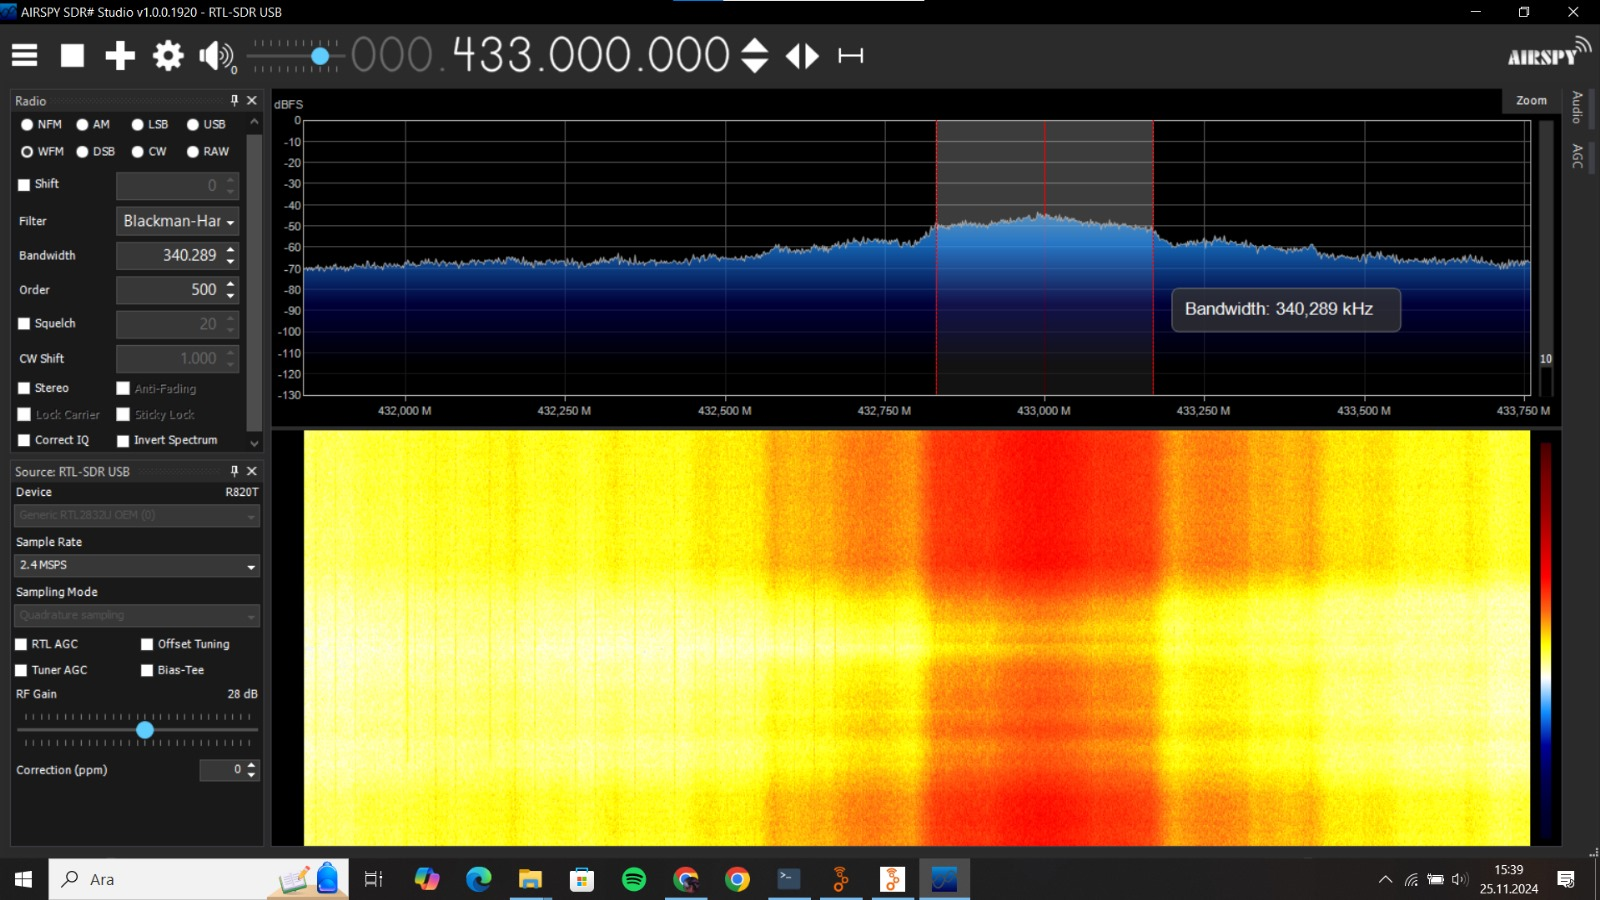


## Q2: What is the bandwidth of the transmitted signal? (30pts)

## A2:
340.289 kHz. Bu bant genişliği yaklaşık -3dB farkın oluştuğu yere bakılarak bulundu.

## Q3: The roll-off factor is a measure of excess bandwidth of the filter. Given that roll-off factor of RRC filter is set to 0.35 for the transmitted signal, what is the baud rate of the signal? (30pts)

## A3:
roll-off-factor 0 iken, Bt(transmission bandwith) 340 kHz olarak bulmuşturk. Nyquist frekansı ve bit rate hesabı aşağıdaki şekildedir;  

B0 = Bt/(1+a) = 340/1.35 = 251 kHz = 1/2Tb -> 1/Tb = 502 kHz (bitrate)

2 bitlik QPSK modilasyon yaptığımızdan sembol oranı 502 kHz/2 = 251 kHz gelmektedir.